In [1]:
import os, json, random, shutil, zipfile, hashlib, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, precision_recall_fscore_support)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

# ======================= CONFIGURATION =======================
SEED = 42
CLASS_NAMES = ["cardboard", "glass", "metal", "paper", "plastic", "trash"]
NUM_CLASSES = len(CLASS_NAMES)

IMG_SIZE = 224
BATCH_SIZE = 32

BACKBONE = "EfficientNetV2B0"          # or "MobileNetV2" (lighter / faster)
UNFREEZE_LAYERS = {"EfficientNetV2B0": 80, "MobileNetV2": 60}

HEAD_EPOCHS = 12          # phase 1: train only the new classifier
FINE_TUNE_EPOCHS = 30     # phase 2: fine-tune top backbone layers
HEAD_LR = 1e-3
FINE_TUNE_LR = 2e-5
PATIENCE_HEAD = 4
PATIENCE_FT = 7
DROPOUT = 0.3
LABEL_SMOOTHING = 0.1

VAL_FRACTION = 0.15
TEST_FRACTION = 0.15
CONF_THRESHOLD = 0.60     # below this, the app says "uncertain"

OUT_DIR = Path("/content/waste_project_outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)
# =============================================================

random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
gpus = tf.config.list_physical_devices("GPU")
print("GPU available:", bool(gpus), gpus)
if not gpus:
    print("⚠️  No GPU found. Training will be slow. "
          "Use Runtime → Change runtime type → T4 GPU.")

TensorFlow: 2.21.0
GPU available: True [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
ZIP_PATH = "/content/archive.zip"
EXTRACT_DIR = Path("/content/garbage_dataset")

already_extracted = EXTRACT_DIR.exists() and any(EXTRACT_DIR.iterdir())

if not already_extracted:
    if not os.path.exists(ZIP_PATH):
        from google.colab import files
        uploaded = files.upload()
        ZIP_PATH = os.path.abspath(next(iter(uploaded)))
    with zipfile.ZipFile(ZIP_PATH) as z:
        z.extractall(EXTRACT_DIR)
    print("Dataset extracted.")
else:
    print("Dataset already extracted - skipping.")

Saving archive.zip to archive.zip
Dataset extracted.


In [3]:
# Find the folder that contains the 6 class sub-folders.
def find_dataset_roots(base):
    roots = []
    for root, dirs, _ in os.walk(base):
        if set(CLASS_NAMES).issubset({d.lower() for d in dirs}):
            roots.append(Path(root))
    return roots

roots = find_dataset_roots(EXTRACT_DIR)
assert roots, "Could not find the 6 class folders inside the zip."
print(f"Found {len(roots)} folder(s) with the class structure:")
for r in roots:
    print("  ", r)

# The Kaggle zip can contain the dataset twice. Using BOTH copies would put
# identical images in train AND test (data leakage), so only the first copy is used.
DATA_ROOT = roots[0]
print("\nUsing:", DATA_ROOT)

folder_for = {d.name.lower(): d.name for d in DATA_ROOT.iterdir() if d.is_dir()}
IMG_EXT = (".jpg", ".jpeg", ".png", ".bmp")

records = []
for idx, cname in enumerate(CLASS_NAMES):
    for p in sorted((DATA_ROOT / folder_for[cname]).iterdir()):
        if p.suffix.lower() in IMG_EXT:
            records.append((str(p), idx))

df = pd.DataFrame(records, columns=["path", "label"])
print("Total images found:", len(df))

Found 2 folder(s) with the class structure:
   /content/garbage_dataset/garbage classification/Garbage classification
   /content/garbage_dataset/Garbage classification/Garbage classification

Using: /content/garbage_dataset/garbage classification/Garbage classification
Total images found: 2527


In [4]:
# Data-quality checks: unreadable files and exact duplicates (same bytes).
def file_md5(path):
    h = hashlib.md5()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1 << 20), b""):
            h.update(chunk)
    return h.hexdigest()

def is_readable(path):
    try:
        with Image.open(path) as im:
            im.verify()
        return True
    except Exception:
        return False

df["readable"] = df["path"].map(is_readable)
print("Unreadable images removed:", int((~df["readable"]).sum()))
df = df[df["readable"]].drop(columns="readable").reset_index(drop=True)

df["md5"] = df["path"].map(file_md5)
cross_class = (df.groupby("md5")["label"].nunique() > 1).sum()
dup_mask = df.duplicated("md5", keep="first")
print("Exact duplicate images removed:", int(dup_mask.sum()),
      f"(of which {int(cross_class)} hash(es) appeared in more than one class)")
df = df[~dup_mask].reset_index(drop=True)

print("\nImages after cleaning:", len(df))

Unreadable images removed: 0
Exact duplicate images removed: 3 (of which 3 hash(es) appeared in more than one class)

Images after cleaning: 2524


    class  images
cardboard     403
    glass     501
    metal     409
    paper     594
  plastic     480
    trash     137

Imbalance ratio (largest / smallest class): 4.34


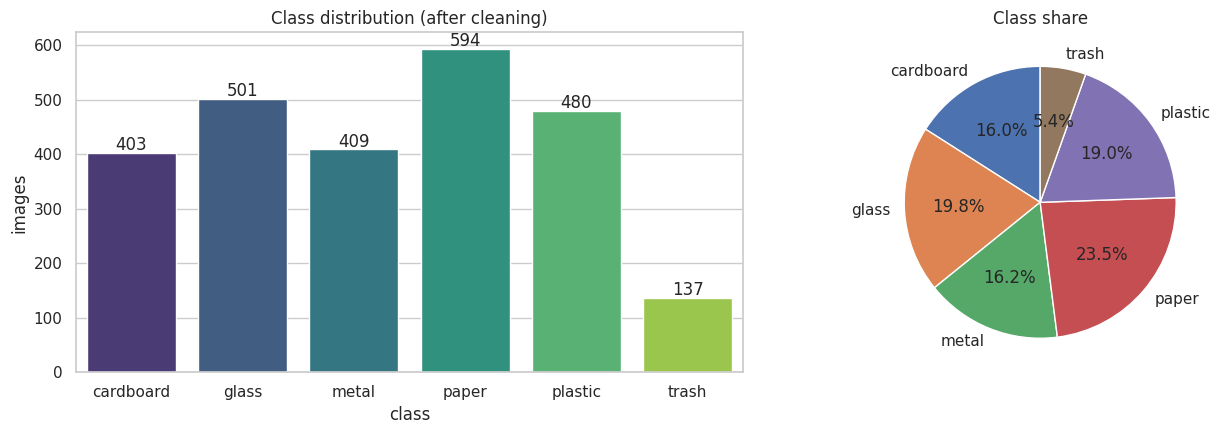

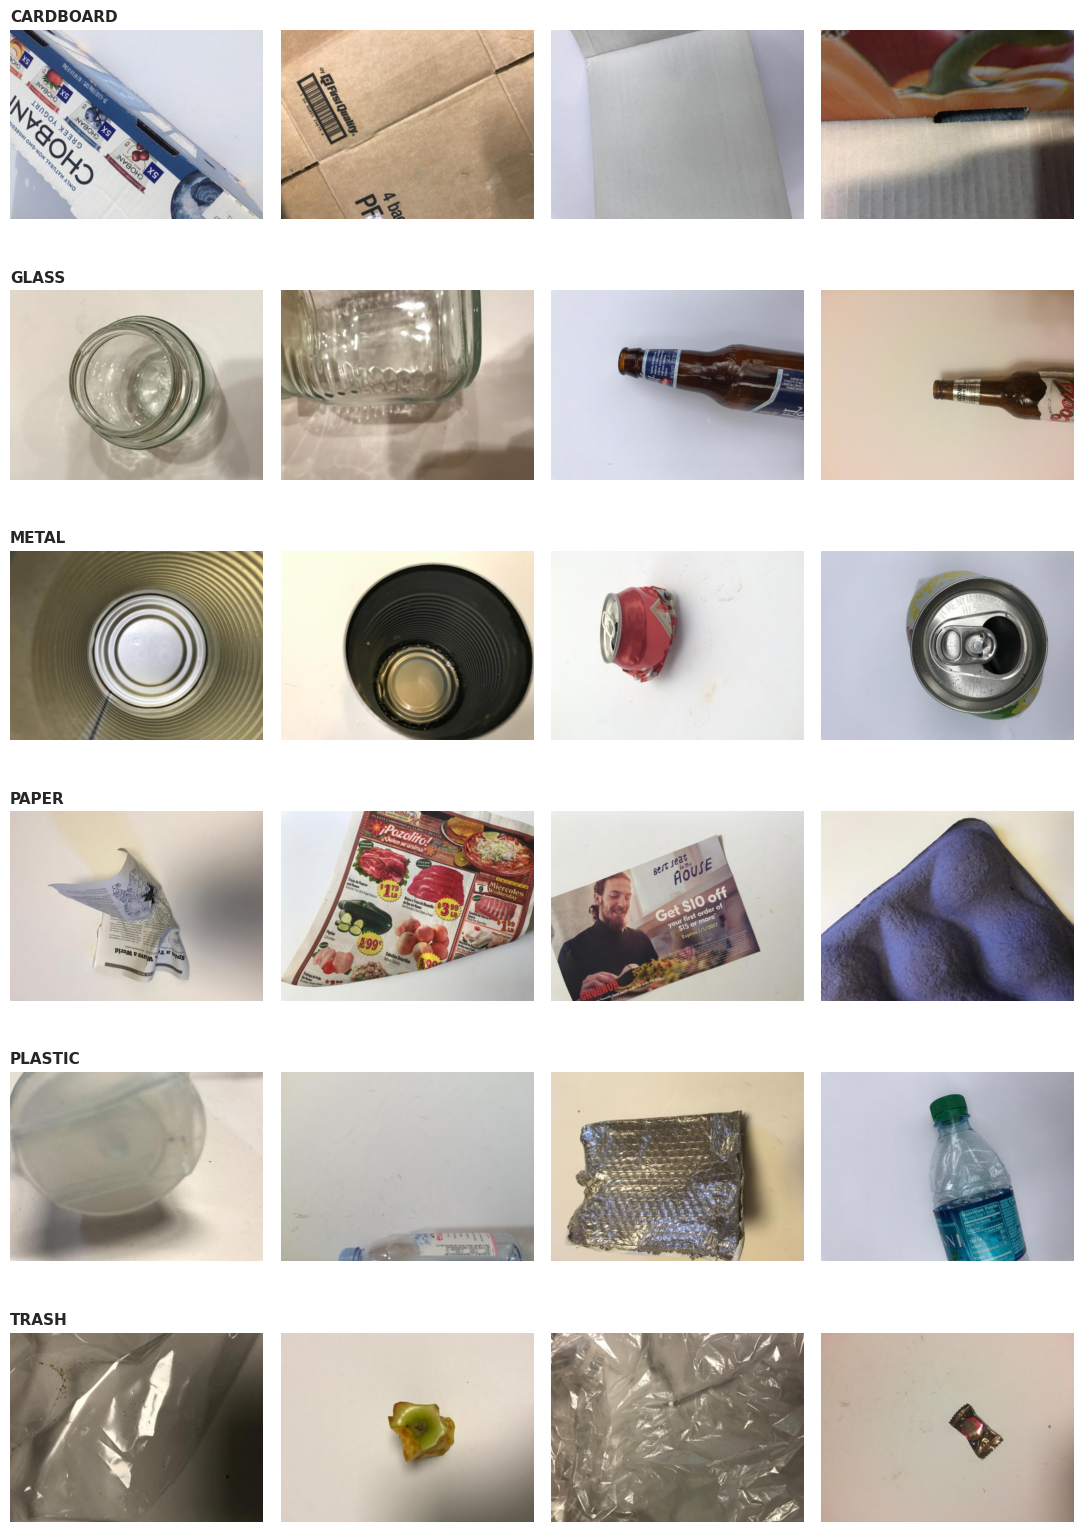

In [5]:
# Exploratory data analysis
counts = df["label"].value_counts().sort_index()
count_df = pd.DataFrame({"class": CLASS_NAMES, "images": counts.values})
print(count_df.to_string(index=False))
print(f"\nImbalance ratio (largest / smallest class): {counts.max() / counts.min():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.barplot(data=count_df, x="class", y="images", hue="class", legend=False, ax=axes[0], palette="viridis")
axes[0].set_title("Class distribution (after cleaning)")
for i, v in enumerate(count_df["images"]):
    axes[0].text(i, v + 5, str(v), ha="center")
axes[1].pie(count_df["images"], labels=CLASS_NAMES, autopct="%1.1f%%", startangle=90)
axes[1].set_title("Class share")
plt.tight_layout()
plt.savefig(OUT_DIR / "class_distribution.png", dpi=150)
plt.show()

# Sample images: 4 per class
fig, axes = plt.subplots(NUM_CLASSES, 4, figsize=(11, 16))
for r, cname in enumerate(CLASS_NAMES):
    sample = df[df.label == r].sample(4, random_state=SEED)
    for c, (_, row) in enumerate(sample.iterrows()):
        axes[r, c].imshow(Image.open(row.path).convert("RGB"))
        axes[r, c].axis("off")
        if c == 0:
            axes[r, c].set_title(cname.upper(), loc="left", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

In [6]:
holdout = VAL_FRACTION + TEST_FRACTION
train_df, temp_df = train_test_split(df, test_size=holdout, stratify=df["label"], random_state=SEED)
val_df, test_df = train_test_split(temp_df, test_size=TEST_FRACTION / holdout,
                                   stratify=temp_df["label"], random_state=SEED)
train_df, val_df, test_df = [d.reset_index(drop=True) for d in (train_df, val_df, test_df)]

# Safety checks: no file and no identical image may appear in two splits.
assert not set(train_df.path) & set(val_df.path)
assert not set(train_df.path) & set(test_df.path)
assert not set(val_df.path) & set(test_df.path)
assert not set(train_df.md5) & set(val_df.md5)
assert not set(train_df.md5) & set(test_df.md5)
assert not set(val_df.md5) & set(test_df.md5)
print("✅ No overlap between train / validation / test.\n")

split_table = pd.DataFrame({
    "class": CLASS_NAMES,
    "train": train_df.label.value_counts().sort_index().values,
    "val":   val_df.label.value_counts().sort_index().values,
    "test":  test_df.label.value_counts().sort_index().values,
})
split_table.loc[len(split_table)] = ["TOTAL", len(train_df), len(val_df), len(test_df)]
print(split_table.to_string(index=False))

# Class weights: the small 'trash' class gets a larger weight during training.
cw = compute_class_weight("balanced", classes=np.arange(NUM_CLASSES), y=train_df.label.values)
class_weight_tensor = tf.constant(cw, dtype=tf.float32)
print("\nClass weights:", {c: round(float(w), 2) for c, w in zip(CLASS_NAMES, cw)})

✅ No overlap between train / validation / test.

    class  train  val  test
cardboard    282   61    60
    glass    350   75    76
    metal    286   62    61
    paper    416   89    89
  plastic    336   72    72
    trash     96   20    21
    TOTAL   1766  379   379

Class weights: {'cardboard': 1.04, 'glass': 0.84, 'metal': 1.03, 'paper': 0.71, 'plastic': 0.88, 'trash': 3.07}


In [7]:
AUTOTUNE = tf.data.AUTOTUNE

def load_and_resize(path, label):
    raw = tf.io.read_file(path)
    img = tf.io.decode_image(raw, channels=3, expand_animations=False)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE), method="bilinear")
    img = tf.cast(tf.clip_by_value(tf.round(img), 0, 255), tf.uint8)
    img.set_shape((IMG_SIZE, IMG_SIZE, 3))
    return img, label

def make_dataset(frame, training):
    paths = frame["path"].values.astype(str)
    labels = frame["label"].values.astype("int32")
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_and_resize, num_parallel_calls=AUTOTUNE).cache()
    if training:
        ds = ds.shuffle(len(frame), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.batch(BATCH_SIZE)
    if training:   # (image, one-hot label, sample weight from class weights)
        ds = ds.map(lambda x, y: (tf.cast(x, tf.float32),
                                  tf.one_hot(y, NUM_CLASSES),
                                  tf.gather(class_weight_tensor, y)),
                    num_parallel_calls=AUTOTUNE)
    else:
        ds = ds.map(lambda x, y: (tf.cast(x, tf.float32), tf.one_hot(y, NUM_CLASSES)),
                    num_parallel_calls=AUTOTUNE)
    return ds.prefetch(AUTOTUNE)

train_ds = make_dataset(train_df, training=True)
val_ds = make_dataset(val_df, training=False)
test_ds = make_dataset(test_df, training=False)   # NOT shuffled -> order matches test_df
print("Datasets ready.")

Datasets ready.


In [8]:
def build_models():
    if BACKBONE == "EfficientNetV2B0":
        base = keras.applications.EfficientNetV2B0(include_top=False, weights="imagenet",
                                                   input_shape=(IMG_SIZE, IMG_SIZE, 3))
        pre = layers.Rescaling(1.0, name="preprocess")            # scaling is built into EfficientNetV2
    elif BACKBONE == "MobileNetV2":
        base = keras.applications.MobileNetV2(include_top=False, weights="imagenet",
                                              input_shape=(IMG_SIZE, IMG_SIZE, 3))
        pre = layers.Rescaling(1.0 / 127.5, offset=-1.0, name="preprocess")   # -> [-1, 1]
    else:
        raise ValueError("BACKBONE must be 'EfficientNetV2B0' or 'MobileNetV2'")
    base.trainable = False

    augment = keras.Sequential([
        layers.RandomFlip("horizontal_and_vertical"),
        layers.RandomRotation(0.15),
        layers.RandomZoom(0.2),
        layers.RandomTranslation(0.1, 0.1),
        layers.RandomBrightness(0.2, value_range=(0, 255)),
        layers.RandomContrast(0.2),
    ], name="augmentation")

    gap = layers.GlobalAveragePooling2D(name="gap")
    drop = layers.Dropout(DROPOUT, name="dropout")
    clf = layers.Dense(NUM_CLASSES, activation="softmax", name="classifier")

    # ---- training model
    inputs = keras.Input((IMG_SIZE, IMG_SIZE, 3), name="image")
    x = augment(inputs)
    x = pre(x)
    x = base(x, training=False)       # keeps BatchNorm statistics frozen
    x = gap(x)
    x = drop(x)
    train_model = keras.Model(inputs, clf(x), name="waste_classifier_train")

    # ---- inference model (shares the same layers / weights)
    inf_in = keras.Input((IMG_SIZE, IMG_SIZE, 3), name="image")
    y = pre(inf_in)
    y = base(y, training=False)
    y = gap(y)
    infer_model = keras.Model(inf_in, clf(y), name="waste_classifier")

    parts = dict(pre=pre, base=base, gap=gap, clf=clf, augment=augment)
    return train_model, infer_model, parts

model, infer_model, parts = build_models()
base_model = parts["base"]

def count_params(weights):
    return int(sum(np.prod(w.shape) for w in weights))

print("Backbone          :", BACKBONE)
print("Total parameters  :", f"{model.count_params():,}")
print("Trainable (phase 1):", f"{count_params(model.trainable_weights):,}")

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Backbone          : EfficientNetV2B0
Total parameters  : 5,926,998
Trainable (phase 1): 7,686


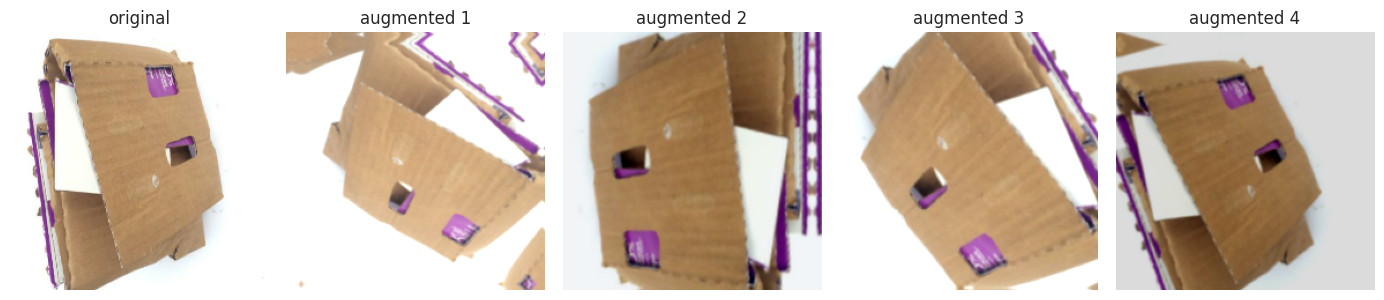

In [9]:
# Visual check of the augmentation: one image, 8 random augmentations.
sample_path = train_df.sample(1, random_state=1).path.iloc[0]
sample_img, _ = load_and_resize(sample_path, 0)
batch = tf.repeat(tf.cast(sample_img[None], tf.float32), 8, axis=0)
aug = parts["augment"](batch, training=True).numpy().clip(0, 255).astype("uint8")

fig, axes = plt.subplots(1, 5, figsize=(14, 3))
axes[0].imshow(sample_img.numpy()); axes[0].set_title("original")
for i in range(1, 5):
    axes[i].imshow(aug[i]); axes[i].set_title(f"augmented {i}")
for a in axes: a.axis("off")
plt.tight_layout(); plt.show()

In [10]:
def compile_model(m, lr):
    m.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss=keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING),
        metrics=[keras.metrics.CategoricalAccuracy(name="accuracy")],
    )

def make_callbacks(tag, patience):
    return [
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=patience,
                                      restore_best_weights=True, verbose=1),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=2,
                                          min_lr=1e-7, verbose=1),
        keras.callbacks.ModelCheckpoint(str(OUT_DIR / f"best_{tag}.weights.h5"),
                                        monitor="val_loss", save_best_only=True,
                                        save_weights_only=True),
    ]

# ---------------- Phase 1: train the classifier head ----------------
compile_model(model, HEAD_LR)
history_head = model.fit(train_ds, validation_data=val_ds, epochs=HEAD_EPOCHS,
                         callbacks=make_callbacks("head", PATIENCE_HEAD), verbose=2)

Epoch 1/12
56/56 - 29s - 512ms/step - accuracy: 0.5306 - loss: 1.3683 - val_accuracy: 0.7335 - val_loss: 0.9956 - learning_rate: 0.0010
Epoch 2/12
56/56 - 5s - 91ms/step - accuracy: 0.7208 - loss: 1.0120 - val_accuracy: 0.7757 - val_loss: 0.8962 - learning_rate: 0.0010
Epoch 3/12
56/56 - 6s - 106ms/step - accuracy: 0.7644 - loss: 0.9249 - val_accuracy: 0.7968 - val_loss: 0.8496 - learning_rate: 0.0010
Epoch 4/12
56/56 - 5s - 91ms/step - accuracy: 0.8052 - loss: 0.8843 - val_accuracy: 0.8100 - val_loss: 0.8347 - learning_rate: 0.0010
Epoch 5/12
56/56 - 5s - 97ms/step - accuracy: 0.7973 - loss: 0.8632 - val_accuracy: 0.8285 - val_loss: 0.8125 - learning_rate: 0.0010
Epoch 6/12
56/56 - 5s - 93ms/step - accuracy: 0.8301 - loss: 0.8149 - val_accuracy: 0.8338 - val_loss: 0.7924 - learning_rate: 0.0010
Epoch 7/12
56/56 - 6s - 98ms/step - accuracy: 0.8375 - loss: 0.8081 - val_accuracy: 0.8364 - val_loss: 0.7890 - learning_rate: 0.0010
Epoch 8/12
56/56 - 5s - 96ms/step - accuracy: 0.8482 - loss

In [11]:
# ---------------- Phase 2: fine-tune the top of the backbone ----------------
base_model.trainable = True
n_unfreeze = UNFREEZE_LAYERS[BACKBONE]
for layer in base_model.layers[:-n_unfreeze]:
    layer.trainable = False
for layer in base_model.layers:                      # keep BatchNorm frozen
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

print(f"Unfroze the last {n_unfreeze} backbone layers.")
print("Trainable parameters now:", f"{count_params(model.trainable_weights):,}")

compile_model(model, FINE_TUNE_LR)                   # must re-compile after changing trainable
history_ft = model.fit(train_ds, validation_data=val_ds, epochs=FINE_TUNE_EPOCHS,
                       callbacks=make_callbacks("finetune", PATIENCE_FT), verbose=2)

Unfroze the last 80 backbone layers.
Trainable parameters now: 3,076,086
Epoch 1/30
56/56 - 31s - 559ms/step - accuracy: 0.8760 - loss: 0.7434 - val_accuracy: 0.8575 - val_loss: 0.7590 - learning_rate: 2.0000e-05
Epoch 2/30
56/56 - 7s - 124ms/step - accuracy: 0.8698 - loss: 0.7321 - val_accuracy: 0.8628 - val_loss: 0.7547 - learning_rate: 2.0000e-05
Epoch 3/30
56/56 - 10s - 178ms/step - accuracy: 0.8726 - loss: 0.7302 - val_accuracy: 0.8602 - val_loss: 0.7517 - learning_rate: 2.0000e-05
Epoch 4/30
56/56 - 6s - 114ms/step - accuracy: 0.8817 - loss: 0.7242 - val_accuracy: 0.8707 - val_loss: 0.7443 - learning_rate: 2.0000e-05
Epoch 5/30
56/56 - 6s - 103ms/step - accuracy: 0.8715 - loss: 0.7197 - val_accuracy: 0.8602 - val_loss: 0.7451 - learning_rate: 2.0000e-05
Epoch 6/30
56/56 - 7s - 123ms/step - accuracy: 0.8811 - loss: 0.7040 - val_accuracy: 0.8734 - val_loss: 0.7356 - learning_rate: 2.0000e-05
Epoch 7/30
56/56 - 7s - 118ms/step - accuracy: 0.9026 - loss: 0.6773 - val_accuracy: 0.8734

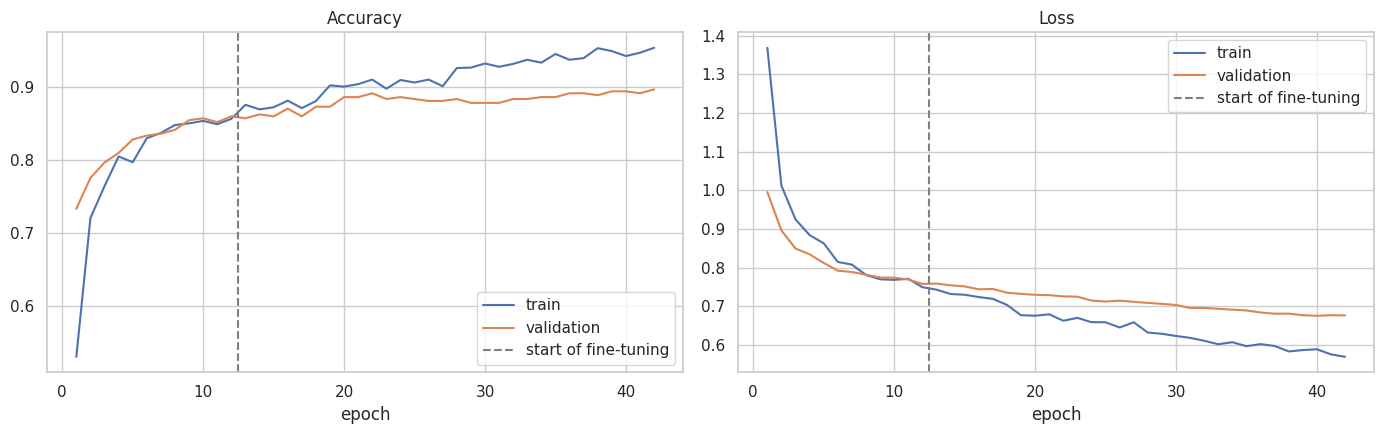

Best validation accuracy: 89.71%


In [12]:
# Training curves (the dashed line marks the start of fine-tuning)
def joined(key):
    return history_head.history[key] + history_ft.history[key]

epochs_run = range(1, len(joined("loss")) + 1)
boundary = len(history_head.history["loss"]) + 0.5

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, key, title in [(axes[0], "accuracy", "Accuracy"), (axes[1], "loss", "Loss")]:
    ax.plot(epochs_run, joined(key), label="train")
    ax.plot(epochs_run, joined("val_" + key), label="validation")
    ax.axvline(boundary, color="gray", linestyle="--", label="start of fine-tuning")
    ax.set_title(title); ax.set_xlabel("epoch"); ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "training_curves.png", dpi=150)
plt.show()

best_val_acc = max(joined("val_accuracy"))
print(f"Best validation accuracy: {best_val_acc * 100:.2f}%")

In [13]:
def collect_images(ds):
    return np.concatenate([x.numpy() for x, _ in ds]).astype("uint8")

val_images, test_images = collect_images(val_ds), collect_images(test_ds)
y_val, y_true = val_df.label.values, test_df.label.values

def predict_probs(m, imgs, tta=False):
    out = []
    for i in range(0, len(imgs), BATCH_SIZE):
        x = imgs[i:i + BATCH_SIZE].astype("float32")
        p = m(x, training=False).numpy()
        if tta:
            p_h = m(np.ascontiguousarray(x[:, :, ::-1, :]), training=False).numpy()
            p_v = m(np.ascontiguousarray(x[:, ::-1, :, :]), training=False).numpy()
            p = (p + p_h + p_v) / 3.0
        out.append(p)
    return np.concatenate(out)

# Decide TTA on the validation set
val_plain = accuracy_score(y_val, predict_probs(infer_model, val_images).argmax(1))
val_tta = accuracy_score(y_val, predict_probs(infer_model, val_images, tta=True).argmax(1))
USE_TTA = val_tta > val_plain
print(f"Validation accuracy  plain: {val_plain*100:.2f}%   TTA: {val_tta*100:.2f}%   -> use TTA: {USE_TTA}")

# Final test predictions
test_probs = predict_probs(infer_model, test_images, tta=USE_TTA)
y_pred = test_probs.argmax(1)
test_acc = accuracy_score(y_true, y_pred)

prec, rec, f1, support = precision_recall_fscore_support(y_true, y_pred, zero_division=0)
macro_p, macro_r, macro_f1 = prec.mean(), rec.mean(), f1.mean()

# Bootstrap 95% confidence interval for accuracy
rng = np.random.default_rng(SEED)
correct = (y_pred == y_true).astype(int)
boot = [rng.choice(correct, size=len(correct), replace=True).mean() for _ in range(5000)]
ci_low, ci_high = np.percentile(boot, [2.5, 97.5])

print("\n" + "=" * 52)
print("            FINAL TEST-SET RESULTS")
print("=" * 52)
print(f"Test images        : {len(y_true)}")
print(f"Accuracy           : {test_acc*100:.2f}%   (95% CI: {ci_low*100:.2f}% - {ci_high*100:.2f}%)")
print(f"Macro precision    : {macro_p*100:.2f}%")
print(f"Macro recall       : {macro_r*100:.2f}%")
print(f"Macro F1-score     : {macro_f1*100:.2f}%")
print("\nPer-class report:\n")
print(classification_report(y_true, y_pred, target_names=[c.capitalize() for c in CLASS_NAMES],
                            digits=4, zero_division=0))

metrics = dict(backbone=BACKBONE, test_images=int(len(y_true)), accuracy=float(test_acc),
               ci95=[float(ci_low), float(ci_high)], macro_precision=float(macro_p),
               macro_recall=float(macro_r), macro_f1=float(macro_f1), used_tta=bool(USE_TTA),
               per_class_f1={c: float(v) for c, v in zip(CLASS_NAMES, f1)})

Validation accuracy  plain: 89.45%   TTA: 89.71%   -> use TTA: True

            FINAL TEST-SET RESULTS
Test images        : 379
Accuracy           : 92.35%   (95% CI: 89.71% - 94.99%)
Macro precision    : 91.43%
Macro recall       : 92.43%
Macro F1-score     : 91.83%

Per-class report:

              precision    recall  f1-score   support

   Cardboard     0.9828    0.9500    0.9661        60
       Glass     0.9714    0.8947    0.9315        76
       Metal     0.8824    0.9836    0.9302        61
       Paper     0.9205    0.9101    0.9153        89
     Plastic     0.9028    0.9028    0.9028        72
       Trash     0.8261    0.9048    0.8636        21

    accuracy                         0.9235       379
   macro avg     0.9143    0.9243    0.9183       379
weighted avg     0.9258    0.9235    0.9237       379



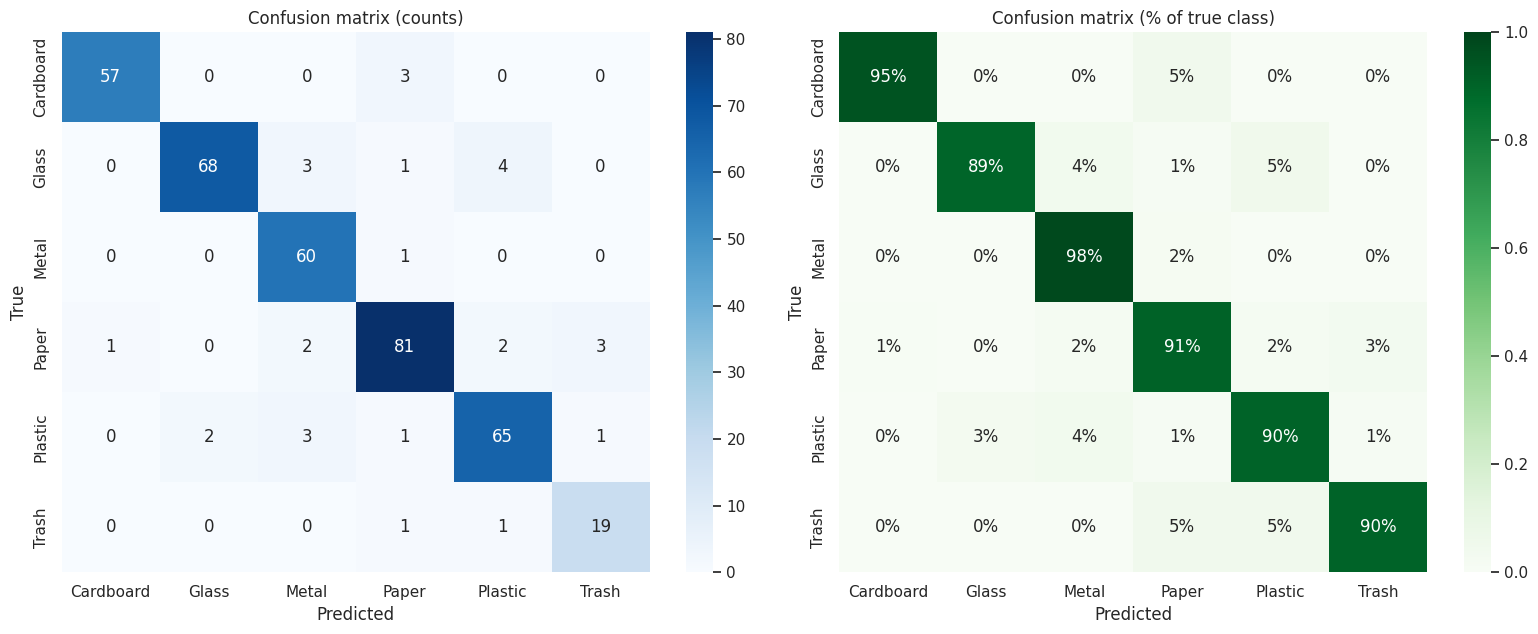

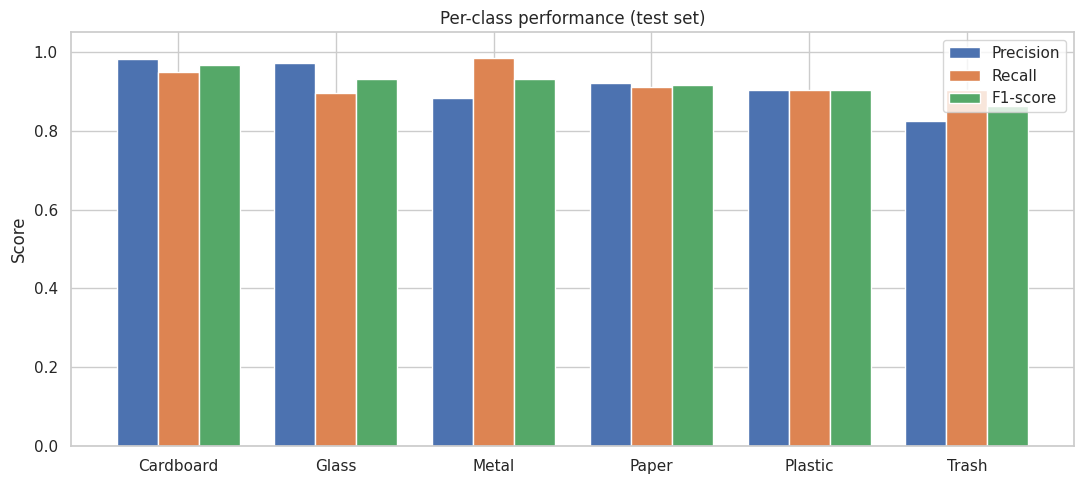

In [14]:
# Confusion matrices (counts and row-normalised)
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm / cm.sum(axis=1, keepdims=True)
labels_cap = [c.capitalize() for c in CLASS_NAMES]

fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels_cap,
            yticklabels=labels_cap, ax=axes[0])
axes[0].set_title("Confusion matrix (counts)")
sns.heatmap(cm_norm, annot=True, fmt=".0%", cmap="Greens", xticklabels=labels_cap,
            yticklabels=labels_cap, ax=axes[1], vmin=0, vmax=1)
axes[1].set_title("Confusion matrix (% of true class)")
for ax in axes:
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.tight_layout()
plt.savefig(OUT_DIR / "confusion_matrix.png", dpi=150)
plt.show()

# Per-class precision / recall / F1
x = np.arange(NUM_CLASSES); w = 0.26
plt.figure(figsize=(11, 5))
plt.bar(x - w, prec, w, label="Precision")
plt.bar(x, rec, w, label="Recall")
plt.bar(x + w, f1, w, label="F1-score")
plt.xticks(x, labels_cap); plt.ylim(0, 1.05); plt.ylabel("Score")
plt.title("Per-class performance (test set)"); plt.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "per_class_metrics.png", dpi=150)
plt.show()

Most frequent confusions (true -> predicted):
  glass      -> plastic   : 4
  cardboard  -> paper     : 3
  glass      -> metal     : 3
  paper      -> trash     : 3
  plastic    -> metal     : 3
  paper      -> metal     : 2


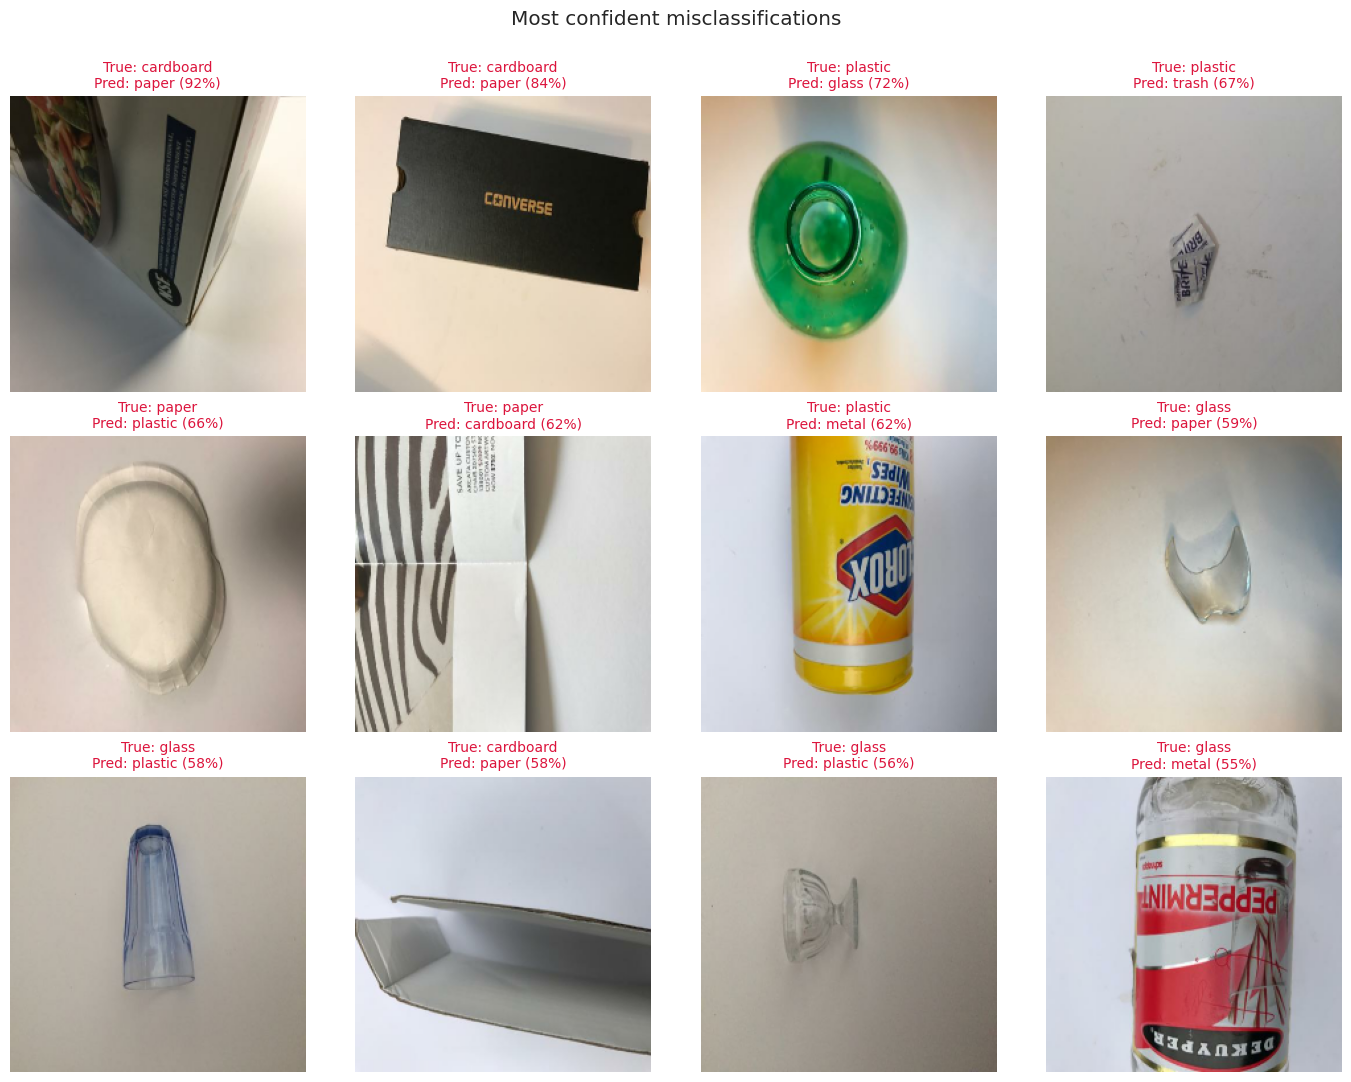

In [15]:
# Error analysis: which classes are confused most, and which mistakes were most confident?
pairs = [(CLASS_NAMES[i], CLASS_NAMES[j], int(cm[i, j]))
         for i in range(NUM_CLASSES) for j in range(NUM_CLASSES) if i != j and cm[i, j] > 0]
pairs.sort(key=lambda t: -t[2])
print("Most frequent confusions (true -> predicted):")
for t, p, n in pairs[:6]:
    print(f"  {t:10s} -> {p:10s}: {n}")

wrong = np.where(y_pred != y_true)[0]
wrong = wrong[np.argsort(-test_probs[wrong].max(axis=1))][:12]   # most confident mistakes first

if len(wrong):
    cols = 4
    rows = int(np.ceil(len(wrong) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(14, 3.6 * rows))
    axes = np.array(axes).reshape(-1)
    for ax, i in zip(axes, wrong):
        ax.imshow(test_images[i])
        ax.set_title(f"True: {CLASS_NAMES[y_true[i]]}\nPred: {CLASS_NAMES[y_pred[i]]} "
                     f"({test_probs[i].max()*100:.0f}%)", fontsize=10, color="crimson")
        ax.axis("off")
    for ax in axes[len(wrong):]:
        ax.axis("off")
    plt.suptitle("Most confident misclassifications", y=1.0)
    plt.tight_layout()
    plt.savefig(OUT_DIR / "misclassified_examples.png", dpi=150)
    plt.show()
else:
    print("No misclassified test images.")

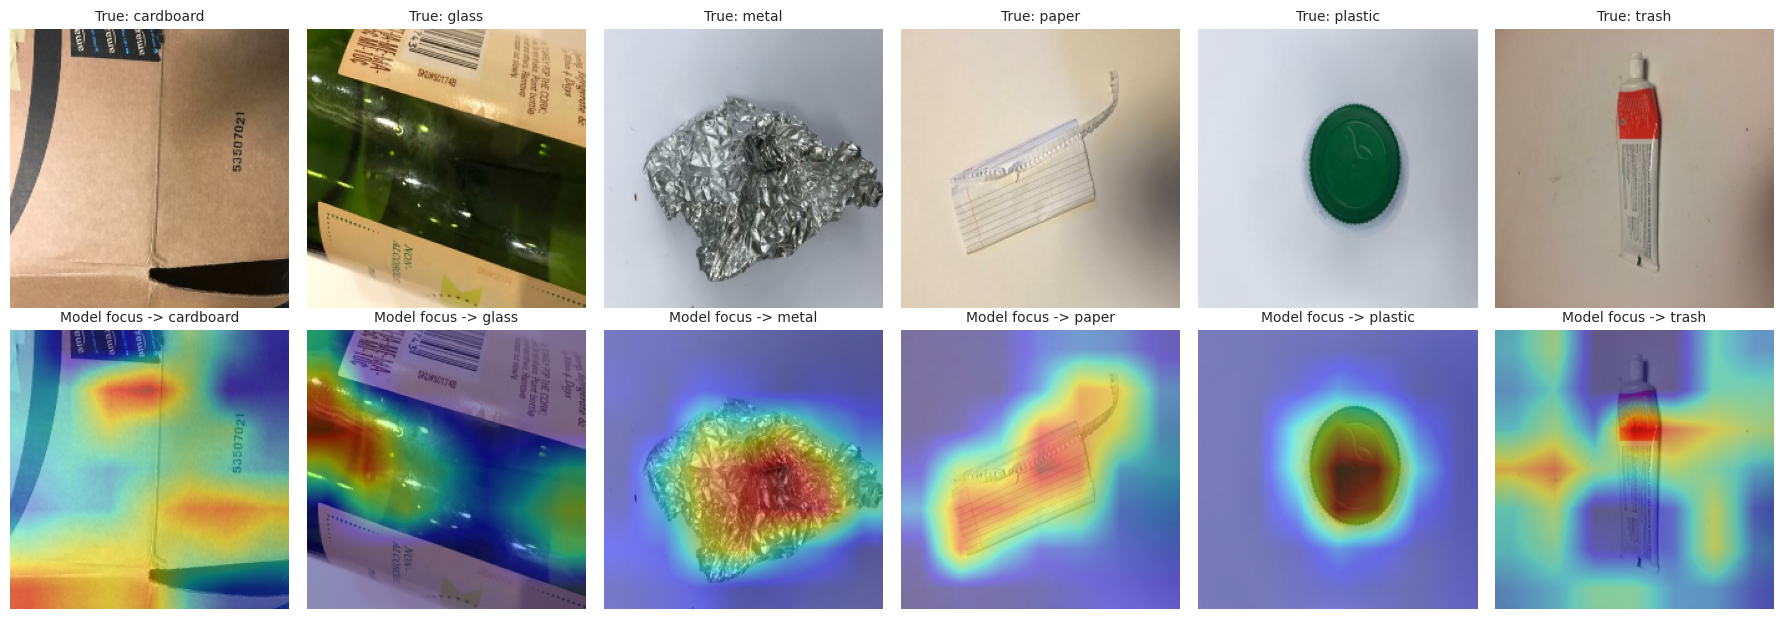

In [16]:
pre_layer, gap_layer, clf_layer = parts["pre"], parts["gap"], parts["clf"]

def gradcam_heatmap(img_uint8, class_idx=None):
    x = tf.convert_to_tensor(img_uint8[None].astype("float32"))
    x = pre_layer(x)
    with tf.GradientTape() as tape:
        fmap = base_model(x, training=False)          # last convolutional feature map
        tape.watch(fmap)
        preds = clf_layer(gap_layer(fmap))
        if class_idx is None:
            class_idx = int(tf.argmax(preds[0]))
        score = preds[:, class_idx]
    grads = tape.gradient(score, fmap)
    channel_weights = tf.reduce_mean(grads, axis=(1, 2))
    cam = tf.reduce_sum(fmap * channel_weights[:, None, None, :], axis=-1)[0]
    cam = tf.nn.relu(cam)
    cam = cam / (tf.reduce_max(cam) + 1e-8)
    return cam.numpy(), class_idx

def overlay_heatmap(img_uint8, cam, alpha=0.45):
    cam_big = tf.image.resize(cam[..., None], (IMG_SIZE, IMG_SIZE)).numpy()[..., 0]
    heat = plt.get_cmap("jet")(cam_big)[..., :3]
    return np.clip((1 - alpha) * img_uint8 / 255.0 + alpha * heat, 0, 1)

# One correctly classified example per class (falls back to any example if none)
fig, axes = plt.subplots(2, NUM_CLASSES, figsize=(3 * NUM_CLASSES, 6.3))
for c in range(NUM_CLASSES):
    ok = np.where((y_true == c) & (y_pred == c))[0]
    idx = ok[0] if len(ok) else np.where(y_true == c)[0][0]
    cam, pred_idx = gradcam_heatmap(test_images[idx])
    axes[0, c].imshow(test_images[idx]); axes[0, c].axis("off")
    axes[0, c].set_title(f"True: {CLASS_NAMES[c]}", fontsize=10)
    axes[1, c].imshow(overlay_heatmap(test_images[idx], cam)); axes[1, c].axis("off")
    axes[1, c].set_title(f"Model focus -> {CLASS_NAMES[pred_idx]}", fontsize=10)
plt.tight_layout()
plt.savefig(OUT_DIR / "gradcam_examples.png", dpi=150)
plt.show()

------------------------------------------------------------ 
Actual: paper


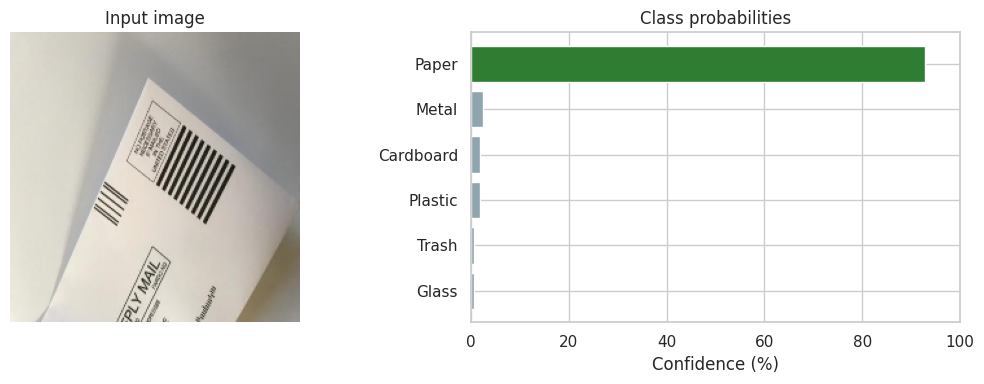

Prediction : PAPER  (92.8%)
  next     : metal (2.4%)
  next     : cardboard (1.9%)
Advice     : Place in the paper recycling bin (keep it dry and clean).
------------------------------------------------------------ 
Actual: glass


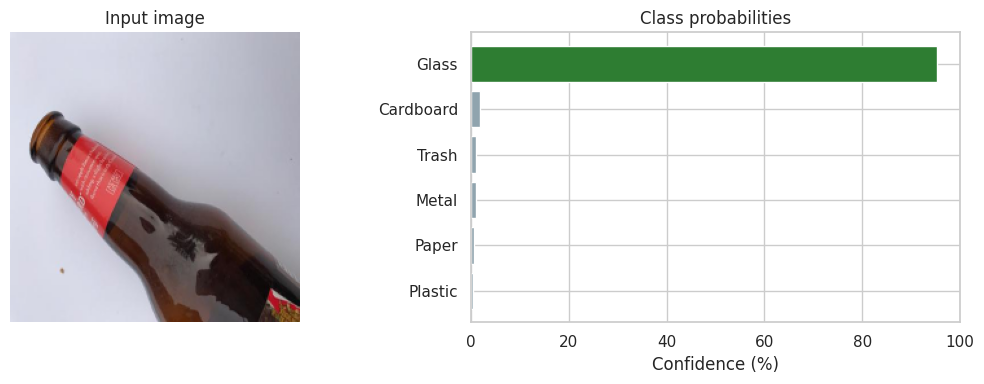

Prediction : GLASS  (95.4%)
  next     : cardboard (1.8%)
  next     : trash (1.0%)
Advice     : Place in the glass recycling bin (rinse first, remove lids).


In [17]:
BIN_ADVICE = {
    "cardboard": "Flatten and place in the dry-paper / cardboard recycling bin.",
    "glass":     "Place in the glass recycling bin (rinse first, remove lids).",
    "metal":     "Place in the metal / cans recycling bin (rinse food residue).",
    "paper":     "Place in the paper recycling bin (keep it dry and clean).",
    "plastic":   "Rinse and place in the plastic recycling bin.",
    "trash":     "General waste bin - not recyclable.",
}

def predict_image(source, top_k=3, show=True):
    if isinstance(source, (str, Path)):
        pil = Image.open(source).convert("RGB")
    else:
        pil = source.convert("RGB")
    arr = tf.image.resize(np.array(pil), (IMG_SIZE, IMG_SIZE), method="bilinear")
    arr = tf.cast(tf.clip_by_value(tf.round(arr), 0, 255), tf.uint8).numpy()

    probs = predict_probs(infer_model, arr[None], tta=True)[0]
    order = probs.argsort()[::-1]
    best = int(order[0])
    confident = probs[best] >= CONF_THRESHOLD

    if show:
        fig, axes = plt.subplots(1, 2, figsize=(11, 4))
        axes[0].imshow(arr); axes[0].axis("off")
        axes[0].set_title("Input image")
        axes[1].barh([CLASS_NAMES[i].capitalize() for i in order[::-1]], probs[order[::-1]] * 100,
                     color=["#2e7d32" if i == best else "#90a4ae" for i in order[::-1]])
        axes[1].set_xlim(0, 100); axes[1].set_xlabel("Confidence (%)")
        axes[1].set_title("Class probabilities")
        plt.tight_layout(); plt.show()

        print(f"Prediction : {CLASS_NAMES[best].upper()}  ({probs[best]*100:.1f}%)")
        for i in order[1:top_k]:
            print(f"  next     : {CLASS_NAMES[i]} ({probs[i]*100:.1f}%)")
        if confident:
            print("Advice     :", BIN_ADVICE[CLASS_NAMES[best]])
        else:
            print("⚠️  Low confidence - please check this item manually.")
    return CLASS_NAMES[best], float(probs[best]), confident

# Try it on a few test images
for i in np.random.default_rng(0).choice(len(test_df), 2, replace=False):
    print("-" * 60, "\nActual:", CLASS_NAMES[y_true[i]])
    predict_image(test_df.path.iloc[i])

Saving WhatsApp Image 2026-10-07 at 1.24.22 AM.jpeg to WhatsApp Image 2026-10-07 at 1.24.22 AM.jpeg
 WhatsApp Image 2026-10-07 at 1.24.22 AM.jpeg


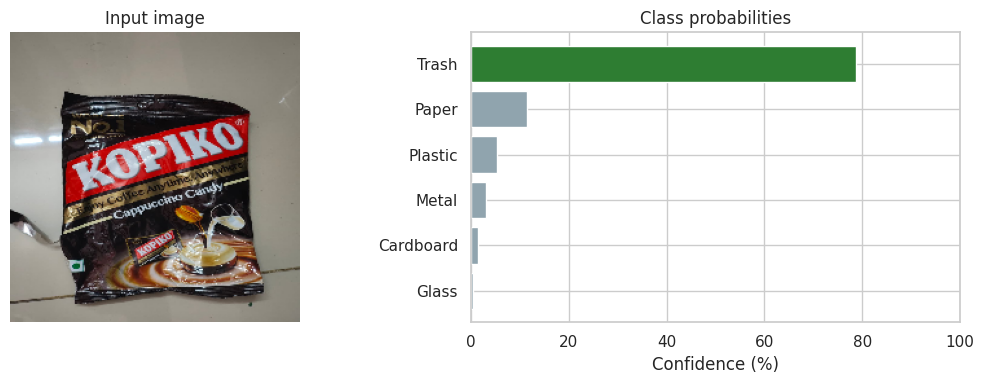

Prediction : TRASH  (78.6%)
  next     : paper (11.4%)
  next     : plastic (5.2%)
Advice     : General waste bin - not recyclable.


In [27]:
# Upload your own photos (waste items) and classify them
try:
    from google.colab import files
    my_files = files.upload()
    for name in my_files:
        print("=" * 60, "\n", name)
        predict_image(name)
except Exception as e:
    print("Upload skipped:", e)

In [20]:
infer_model.save(str(OUT_DIR / "waste_classifier.keras"))
with open(OUT_DIR / "class_names.json", "w") as f:
    json.dump(CLASS_NAMES, f)
with open(OUT_DIR / "metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)
print("Saved Keras model, class names and metrics.")

# TensorFlow Lite export (optional, wrapped so a conversion problem does not stop the notebook)
try:
    converter = tf.lite.TFLiteConverter.from_keras_model(infer_model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    tflite_bytes = converter.convert()
    (OUT_DIR / "waste_classifier.tflite").write_bytes(tflite_bytes)
    print(f"Saved TFLite model ({len(tflite_bytes) / 1e6:.1f} MB).")
except Exception as e:
    print("TFLite export skipped:", e)

shutil.make_archive("/content/waste_project_outputs", "zip", OUT_DIR)
print("Created /content/waste_project_outputs.zip")
try:
    from google.colab import files
    files.download("/content/waste_project_outputs.zip")
except Exception:
    pass

Saved Keras model, class names and metrics.
Saved artifact at '/tmp/tmp7du3hhu0'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='image')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  134277458399248: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  134277458398096: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  134277458400592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134277458400400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134277458400976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134277458401744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134277458401168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134277458400784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134277458401936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134277458401360: TensorSpec(s

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [26]:
# OPTIONAL: web demo with Gradio (drag-and-drop an image, get the class + confidence).
# Creates a temporary public link while this cell is running.
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "gradio"], check=False)
import gradio as gr

def classify_for_demo(pil_img):
    if pil_img is None:
        return {}
    arr = tf.image.resize(np.array(pil_img.convert("RGB")), (IMG_SIZE, IMG_SIZE))
    arr = tf.cast(tf.clip_by_value(tf.round(arr), 0, 255), tf.uint8).numpy()
    probs = predict_probs(infer_model, arr[None], tta=True)[0]
    return {CLASS_NAMES[i].capitalize(): float(probs[i]) for i in range(NUM_CLASSES)}

demo = gr.Interface(
    fn=classify_for_demo,
    inputs=gr.Image(type="pil", label="Waste image"),
    outputs=gr.Label(num_top_classes=3, label="Prediction"),
    title="Smart Waste Classification",
    description="Upload a photo of a waste item to classify it as cardboard, glass, metal, paper, plastic or trash.",
)
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e6394f313a74ceedcb.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
